# Paso 4: Generación de modelos y GridSearchCV

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
df = pd.read_csv('datos_1980-2025_procesados_fatigue.csv')
df.head()

,Age,MP,PER,TS%,FTr,TRB%,AST%,STL%,USG%,W/L%,...,MVP_Rank,Awards,Player,Team,prominence_score,fatigue_decay,fatigue_streak,is_defending_mvp,MVP_Category,MVP_Performance_Category
0,27.0,2055.0,19.5,0.617,0.413,12.5,14.2,1.3,21.1,0.646,...,0,No awards,Aaron Gordon,DEN,0.000000,0.000000,0.0,0,No MVP Votes,Outside Top 5
1,25.0,1286.0,18.7,0.563,0.361,11.5,11.6,1.5,24.6,0.463,...,0,No awards,Abdul Jeelani,POR,0.000000,0.000000,0.0,0,No MVP Votes,Outside Top 5
2,24.0,2674.0,24.3,0.635,0.415,11.3,12.3,1.8,27.8,0.293,...,0,AS,Adrian Dantley,UTA,0.000000,0.000000,0.0,0,No MVP Votes,Outside Top 5
3,25.0,3417.0,24.3,0.622,0.482,8.5,16.3,1.6,28.4,0.341,...,12,"MVP-12,AS,NBA2",Adrian Dantley,UTA,0.083333,0.000000,0.0,0,Outside Top 5 (with votes),Outside Top 5
4,26.0,3222.0,24.2,0.631,0.516,8.6,15.5,1.4,27.9,0.305,...,15,"MVP-15,AS",Adrian Dantley,UTA,0.066667,0.083333,0.0,0,Outside Top 5 (with votes),Outside Top 5


## Definición de variables a usar

In [3]:
FEATURES_RENDIMIENTO = [
    'Age',
    'MP',
    'PER',
    'TS%',
    'FTr',
    'TRB%',
    'AST%',
    'STL%',
    'USG%',
    'W/L%'
]

FEATURES_FATIGA = [
    'fatigue_decay',
    'fatigue_streak',
    'is_defending_mvp'
]

TARGET = 'Share'

## Definición de pipelines

In [4]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipeline_rf = Pipeline([
    ('model', RandomForestRegressor(random_state=42))
])

pipeline_xgb = Pipeline([
    ('model', XGBRegressor(random_state=42))
])

## Definición de escenarios

In [5]:
ESC1 = FEATURES_RENDIMIENTO
ESC2 = FEATURES_RENDIMIENTO + FEATURES_FATIGA

## Definición de función Cross Validate

In [6]:
def cross_validate_by_season(df, features, target, pipeline):
  seasons = sorted(df['Season'].unique())
  results = []

  for test_season in seasons:
    # División temporal
    train = df[df['Season'] != test_season]
    test  = df[df['Season'] == test_season]
    X_train = train[features]
    y_train = train[target]
    X_test  = test[features]
    y_test  = test[target]

    # Entrenar y predecir
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
      'season':  test_season,
      'r2':   r2_score(y_test, y_pred),
      'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
      'mae':  mean_absolute_error(y_test, y_pred),
      'n_test': len(y_test),
      'y_test':  y_test.values,
      'y_pred':  y_pred,
      'X_test':  X_test
    })

  return pd.DataFrame(results)

## Entrenamiento de modelos base

In [7]:
modelos = {
  'LinearRegression': pipeline_lr,
  'RandomForest': pipeline_rf,
  'XGBoost': pipeline_xgb,
}

escenarios = {
  'Scenario1_SinFatiga': FEATURES_RENDIMIENTO,
  'Scenario2_ConFatiga': FEATURES_RENDIMIENTO + FEATURES_FATIGA,
}

all_results = {}

In [8]:
for escenario_name, features in escenarios.items():
  for model_name, pipeline in modelos.items():
    key = f"{escenario_name}_{model_name}"
    print(f"Entrenando: {key}...")

    cv_results = cross_validate_by_season(df, features, TARGET, pipeline)

    all_results[key] = {
      'r2_mean': cv_results['r2'].mean(),
      'r2_std': cv_results['r2'].std(),
      'rmse_mean': cv_results['rmse'].mean(),
      'mae_mean':  cv_results['mae'].mean(),
      'by_season': cv_results,
    }

Entrenando: Scenario1_SinFatiga_LinearRegression...
Entrenando: Scenario1_SinFatiga_RandomForest...
Entrenando: Scenario1_SinFatiga_XGBoost...
Entrenando: Scenario2_ConFatiga_LinearRegression...
Entrenando: Scenario2_ConFatiga_RandomForest...
Entrenando: Scenario2_ConFatiga_XGBoost...


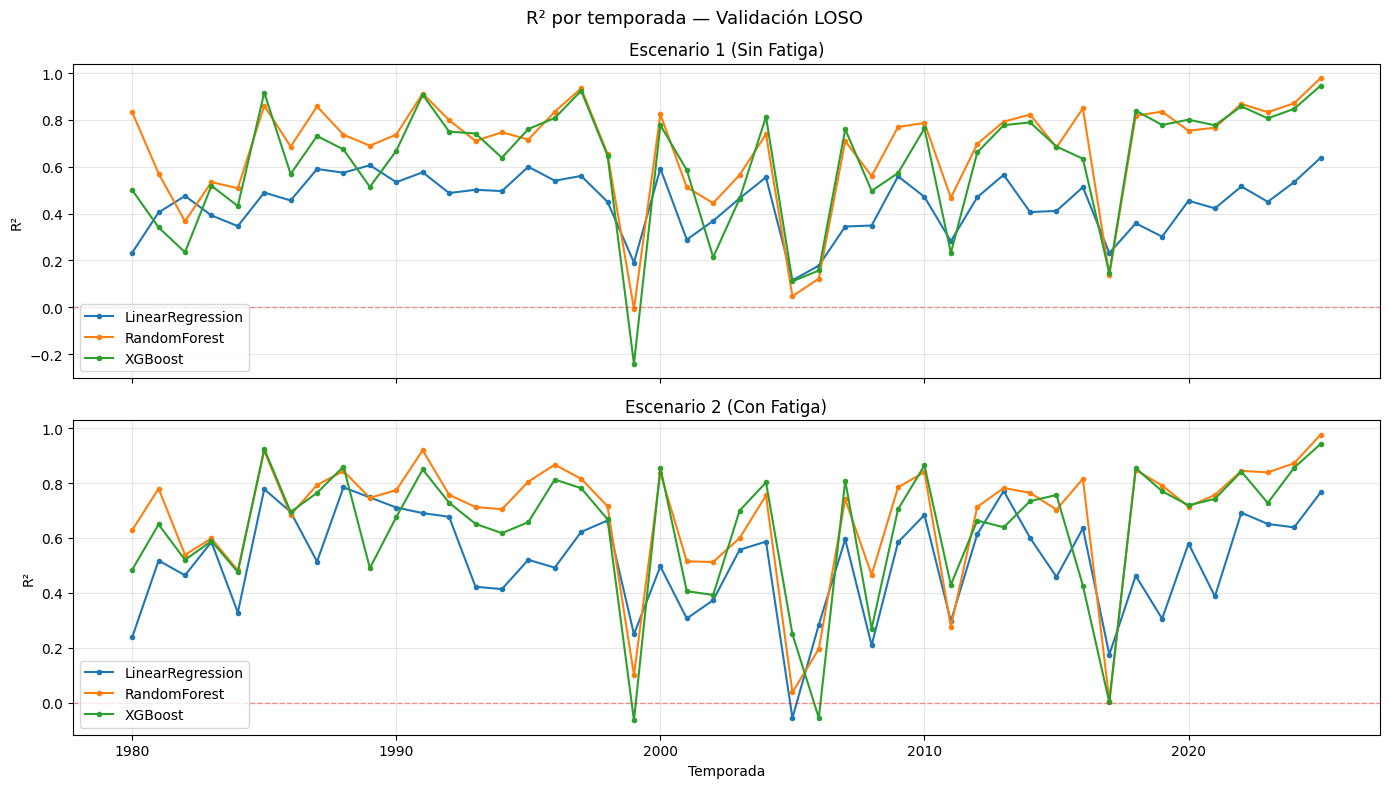

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, (escenario_name, features) in zip(axes, escenarios.items()):
    for model_name in modelos.keys():
        key = f"{escenario_name}_{model_name}"
        by_season = all_results[key]['by_season']
        ax.plot(by_season['season'], by_season['r2'], marker='o', markersize=3, label=model_name)

    ax.axhline(0, color='red', linestyle='--', alpha=0.4, linewidth=1)
    ax.set_title(escenario_name.replace('Scenario', 'Escenario ').replace('_', ' ').replace('Sin', '(Sin ').replace('Con', '(Con ').replace('Fatiga', 'Fatiga)'))
    ax.set_ylabel('R²')
    ax.legend()
    ax.grid(alpha=0.3)

axes[0].set_xlabel('')
axes[1].set_xlabel('Temporada')

plt.suptitle('R² por temporada — Validación LOSO', fontsize=13)
plt.tight_layout()
plt.savefig('r2_por_temporada.png', dpi=150, bbox_inches='tight')
plt.show()

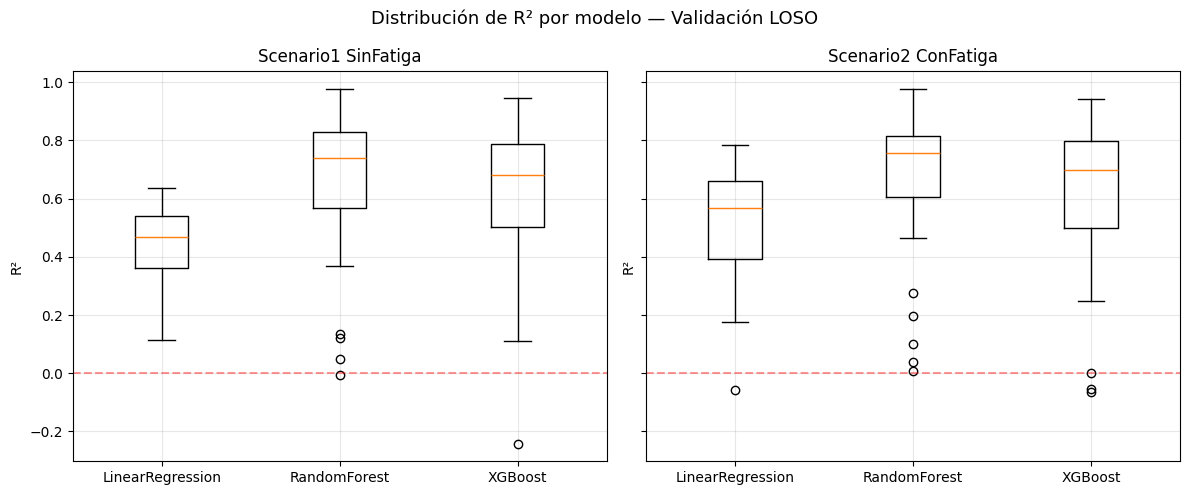

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (escenario_name, _) in zip(axes, escenarios.items()):
    data_box = {
        model_name: all_results[f"{escenario_name}_{model_name}"]['by_season']['r2'].values
        for model_name in modelos.keys()
    }
    ax.boxplot(data_box.values(), tick_labels=data_box.keys())
    ax.axhline(0, color='red', linestyle='--', alpha=0.4)
    ax.set_title(escenario_name.replace('_', ' '))
    ax.set_ylabel('R²')
    ax.grid(alpha=0.3)

plt.suptitle('Distribución de R² por modelo — Validación LOSO', fontsize=13)
plt.tight_layout()
plt.savefig('boxplot_r2.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
results_df = pd.DataFrame.from_dict(all_results, orient='index')
display(results_df)

,r2_mean,r2_std,rmse_mean,mae_mean,by_season
Scenario1_SinFatiga_LinearRegression,0.442483,0.126539,0.130910,0.085144,season r2 rmse mae n_te...
Scenario1_SinFatiga_RandomForest,0.672643,0.230919,0.095658,0.040720,season r2 rmse mae n_te...
Scenario1_SinFatiga_XGBoost,0.615991,0.258636,0.103512,0.045134,season r2 rmse mae n_te...
Scenario2_ConFatiga_LinearRegression,0.516783,0.189095,0.120387,0.073213,season r2 rmse mae n_te...
Scenario2_ConFatiga_RandomForest,0.677780,0.229153,0.094766,0.040182,season r2 rmse mae n_te...
Scenario2_ConFatiga_XGBoost,0.629084,0.243655,0.102239,0.043713,season r2 rmse mae n_te...


# GridSearchCV para Random forest y XGBoost

En la regresión lineal no se aplicará GridSearchCV

### Escenario 1

In [ ]:
# Escenario 1
groups_esc1 = df['Season'].values
logo_esc1 = LeaveOneGroupOut()


X_esc1 = df[FEATURES_RENDIMIENTO]
y_esc1 = df[TARGET]

param_grid_rf_esc1 = {
    'model__n_estimators':    [100, 200, 300],
    'model__max_depth':       [3, 5, 8, None],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features':    ['sqrt', 0.5],
}

gs_rf_esc1 = GridSearchCV(pipeline_rf, param_grid_rf_esc1,
                     cv=logo_esc1, scoring='r2',
                     n_jobs=-1, verbose=1)

gs_rf_esc1.fit(X_esc1, y_esc1, groups=groups_esc1)
print(f"Mejores params RF_esc1: {gs_rf_esc1.best_params_}")
print(f"Mejor R² RF_esc1:       {gs_rf_esc1.best_score_:.4f}")

# XGBoost
param_grid_xgb_esc1 = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [3, 4, 6],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample':     [0.7, 0.9, 1.0],
}

gs_xgb_esc1 = GridSearchCV(pipeline_xgb, param_grid_xgb_esc1,
                      cv=logo_esc1, scoring='r2',
                      n_jobs=-1, verbose=1)

gs_xgb_esc1.fit(X_esc1, y_esc1, groups=groups_esc1)
print(f"Mejores params XGB_esc1: {gs_xgb_esc1.best_params_}")
print(f"Mejor R² XGB_esc1:       {gs_xgb_esc1.best_score_:.4f}")

### Resultados


| Modelo | Mejores Hiperparámetros | Mejor R² |
|--------|--------------------------|----------|
| RF     | `max_depth=None, max_features=0.5, min_samples_split=2, n_estimators=300` | 0.6893   |
| XGB    | `learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.7` | 0.7063   |

### Escenario 2

In [ ]:
# Escenario 2
groups = df['Season'].values
logo = LeaveOneGroupOut()

X = df[FEATURES_RENDIMIENTO + FEATURES_FATIGA] # Añadimos las variables de fatiga
y = df[TARGET]

param_grid_rf = {
    'model__n_estimators':    [100, 200, 300],
    'model__max_depth':       [3, 5, 8, None],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features':    ['sqrt', 0.5],
}

gs_rf = GridSearchCV(pipeline_rf, param_grid_rf,
                     cv=logo, scoring='r2',
                     n_jobs=-1, verbose=1)

gs_rf.fit(X, y, groups=groups)
print(f"Mejores params RF: {gs_rf.best_params_}")
print(f"Mejor R² RF:       {gs_rf.best_score_:.4f}")

param_grid_xgb = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [3, 4, 6],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample':     [0.7, 0.9, 1.0],
}

gs_xgb = GridSearchCV(pipeline_xgb, param_grid_xgb,
                      cv=logo, scoring='r2',
                      n_jobs=-1, verbose=1)

gs_xgb.fit(X, y, groups=groups)
print(f"Mejores params XGB: {gs_xgb.best_params_}")
print(f"Mejor R² XGB:       {gs_xgb.best_score_:.4f}")

### Resultados

| Modelo | Mejores Hiperparámetros | Mejor R² |
|--------|--------------------------|----------|
| RF     | `max_depth=None, max_features=0.5, min_samples_split=5, n_estimators=100` | 0.6816   |
| XGB    | `learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.7` | 0.7063   |

In [ ]:
# Almacenamos los resultados para evitar tener que lanzar el proceso todo el tiempo
with open('gridsearch_objects.pkl', 'wb') as f:
    pickle.dump({
        'gs_rf_esc1': gs_rf_esc1,
        'gs_rf_esc2': gs_rf,
        'gs_xgb_esc1': gs_xgb_esc1,
        'gs_xgb_esc2': gs_xgb,
    }, f)

In [12]:
# De la misma manera, importamos los datos
with open('gridsearch_objects.pkl', 'rb') as f:
    gs_objects = pickle.load(f)

gs_rf_esc1  = gs_objects['gs_rf_esc1']
gs_rf_esc2  = gs_objects['gs_rf_esc2']
gs_xgb_esc1 = gs_objects['gs_xgb_esc1']
gs_xgb_esc2 = gs_objects['gs_xgb_esc2']

print("GridSearch objects cargados correctamente")
print(f"RF Esc1 - Mejor score: {gs_rf_esc1.best_score_:.4f} | Params: {gs_rf_esc1.best_params_}")
print(f"RF Esc2 - Mejor score: {gs_rf_esc2.best_score_:.4f} | Params: {gs_rf_esc2.best_params_}")
print(f"XGB Esc1 - Mejor score: {gs_xgb_esc1.best_score_:.4f} | Params: {gs_xgb_esc1.best_params_}")
print(f"XGB Esc2 - Mejor score: {gs_xgb_esc2.best_score_:.4f} | Params: {gs_xgb_esc2.best_params_}")

GridSearch objects cargados correctamente
RF Esc1 - Mejor score: 0.6893 | Params: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_split': 2, 'model__n_estimators': 300}
RF Esc2 - Mejor score: 0.6816 | Params: {'model__max_depth': None, 'model__max_features': 0.5, 'model__min_samples_split': 5, 'model__n_estimators': 100}
XGB Esc1 - Mejor score: 0.7063 | Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.7}
XGB Esc2 - Mejor score: 0.7063 | Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.7}


/tmp/ipykernel_20977/2107505938.py:3: UserWarning: [17:10:24] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  gs_objects = pickle.load(f)


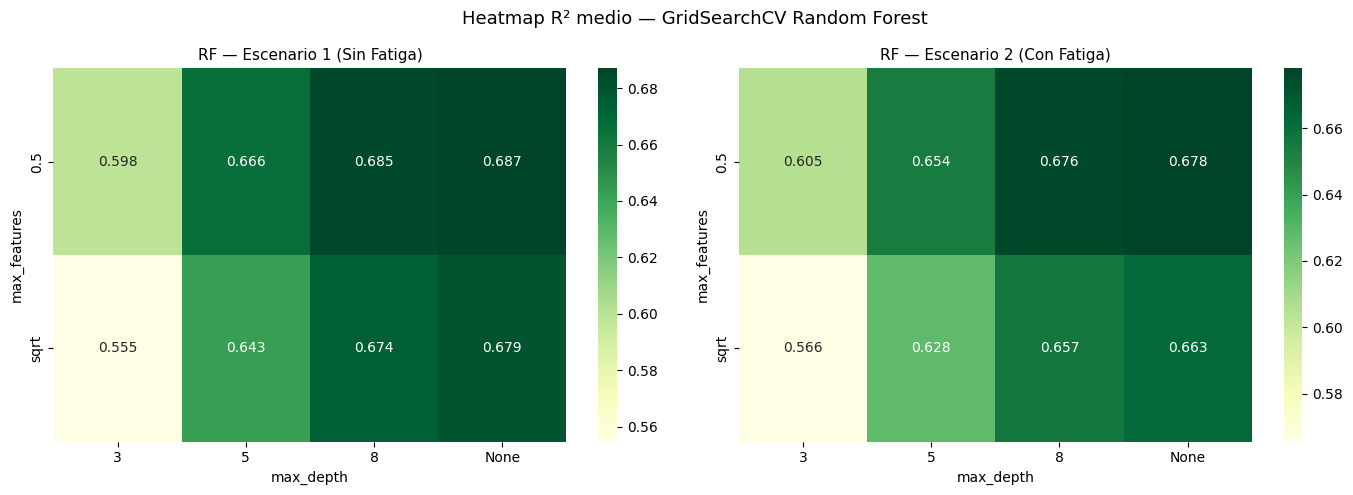

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs_rf = [
    (gs_rf_esc1, 'RF — Escenario 1 (Sin Fatiga)', axes[0]),
    (gs_rf_esc2, 'RF — Escenario 2 (Con Fatiga)', axes[1]),
]

for gs, title, ax in configs_rf:
    df_cv = pd.DataFrame(gs.cv_results_)

    df_cv['param_model__max_depth'] = df_cv['param_model__max_depth'].fillna('None').astype(str)

    pivot = df_cv.pivot_table(
        values='mean_test_score',
        index='param_model__max_features',
        columns='param_model__max_depth',
        aggfunc='mean'
    )

    cols_order = [c for c in ['3', '5', '8', 'None'] if c in pivot.columns]
    pivot = pivot[cols_order]

    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax, cbar=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('max_features')

plt.suptitle('Heatmap R² medio — GridSearchCV Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig('gridsearch_heatmap_rf.png', dpi=150, bbox_inches='tight')
plt.show()

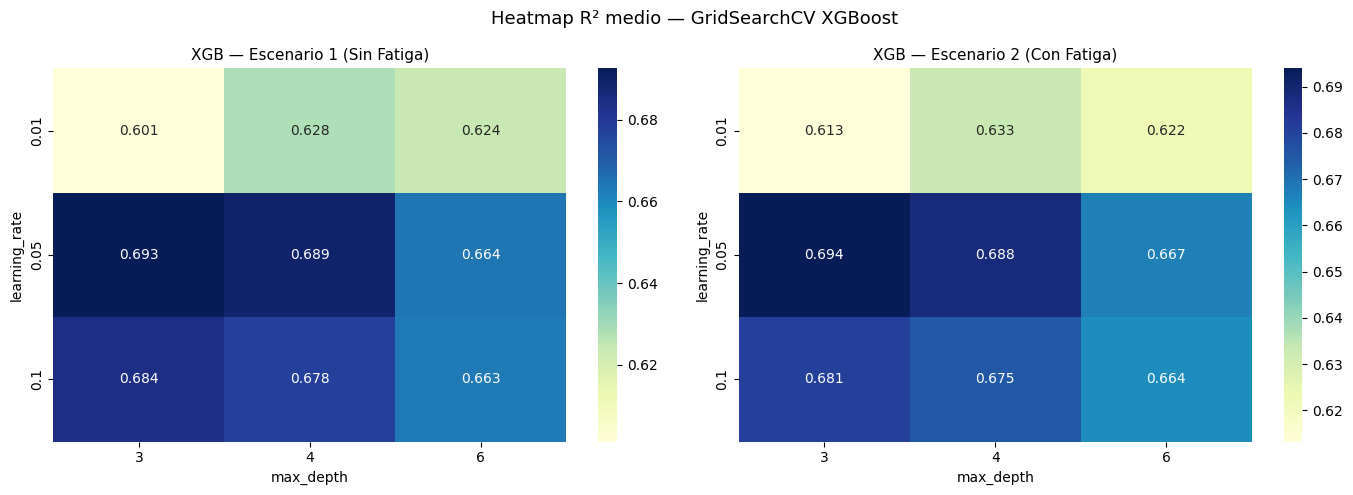

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

configs_xgb = [
    (gs_xgb_esc1, 'XGB — Escenario 1 (Sin Fatiga)', axes[0]),
    (gs_xgb_esc2, 'XGB — Escenario 2 (Con Fatiga)', axes[1]),
]

for gs, title, ax in configs_xgb:
    df_cv = pd.DataFrame(gs.cv_results_)

    pivot = df_cv.pivot_table(
        values='mean_test_score',
        index='param_model__learning_rate',
        columns='param_model__max_depth',
        aggfunc='mean'
    )
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, cbar=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('max_depth')
    ax.set_ylabel('learning_rate')

plt.suptitle('Heatmap R² medio — GridSearchCV XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('gridsearch_heatmap_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

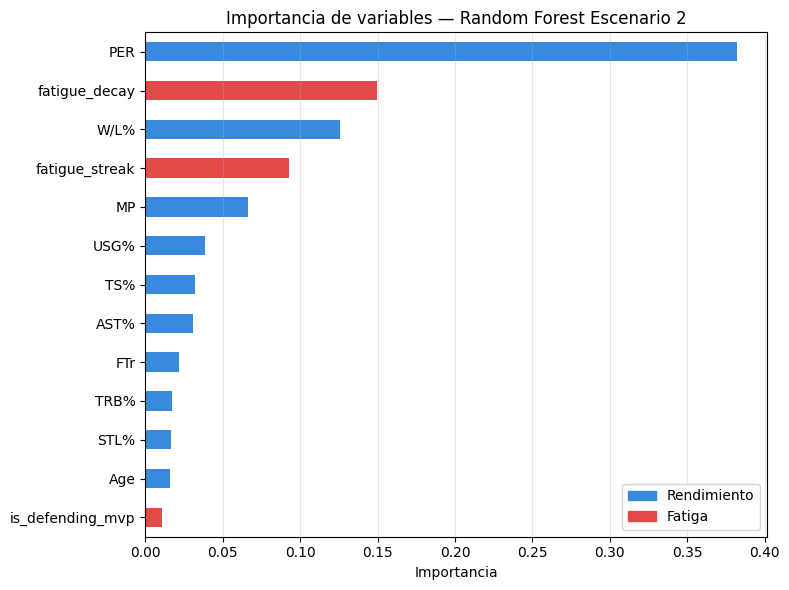

In [15]:
best_rf_esc2 = gs_rf_esc2.best_estimator_

importances = pd.Series(
    best_rf_esc2.named_steps['model'].feature_importances_,
    index=FEATURES_RENDIMIENTO + FEATURES_FATIGA
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E24B4A' if f in FEATURES_FATIGA else '#378ADD' for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Importancia de variables — Random Forest Escenario 2', fontsize=12)
ax.set_xlabel('Importancia')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#378ADD', label='Rendimiento'),
    Patch(color='#E24B4A', label='Fatiga')
])

plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

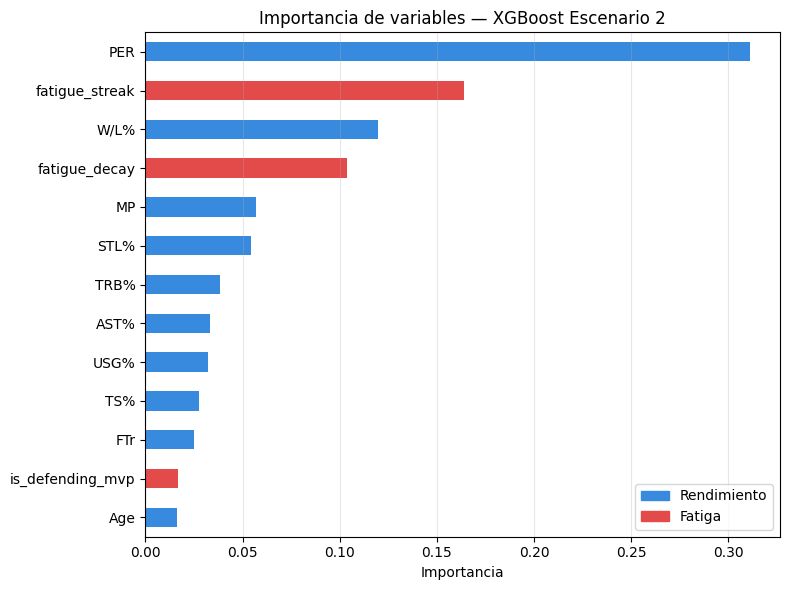

In [16]:
best_xgb_esc2 = gs_xgb_esc2.best_estimator_

importances = pd.Series(
    best_xgb_esc2.named_steps['model'].feature_importances_,
    index=FEATURES_RENDIMIENTO + FEATURES_FATIGA
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E24B4A' if f in FEATURES_FATIGA else '#378ADD' for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Importancia de variables — XGBoost Escenario 2', fontsize=12)
ax.set_xlabel('Importancia')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#378ADD', label='Rendimiento'),
    Patch(color='#E24B4A', label='Fatiga')
])

plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

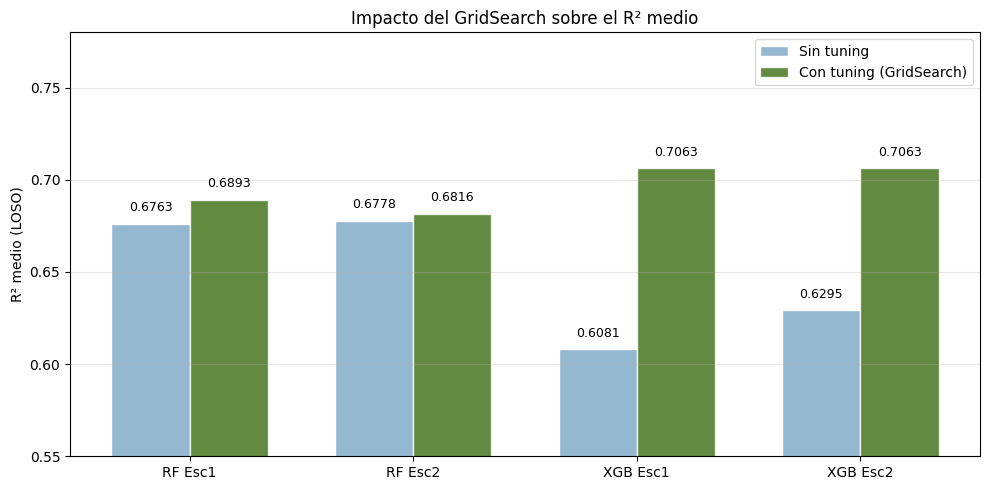

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

modelos_labels = ['RF Esc1', 'RF Esc2', 'XGB Esc1', 'XGB Esc2']
r2_antes  = [0.676267, 0.6778, 0.608115, 0.629498]
r2_despues = [0.6893, 0.6816, 0.7063, 0.7063]

x = range(len(modelos_labels))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], r2_antes,  width, label='Sin tuning', color='#95B8D1', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], r2_despues, width, label='Con tuning (GridSearch)', color='#3B6D11', alpha=0.8, edgecolor='white')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(modelos_labels)
ax.set_ylabel('R² medio (LOSO)')
ax.set_ylim(0.55, 0.78)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_title('Impacto del GridSearch sobre el R² medio', fontsize=12)

plt.tight_layout()
plt.savefig('gridsearch_comparativa.png', dpi=150, bbox_inches='tight')
plt.show()

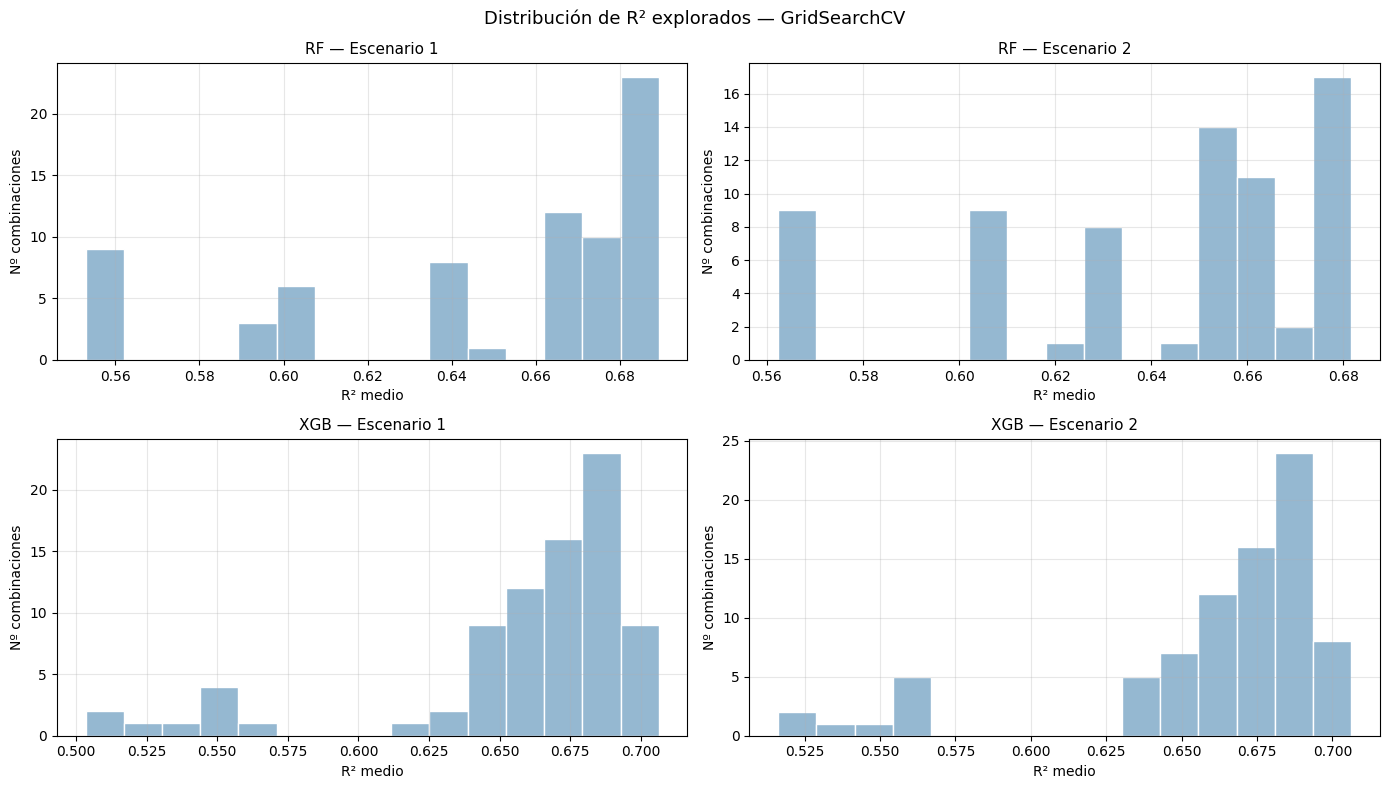

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

configs = [
    (gs_rf_esc1,  'RF — Escenario 1', axes[0,0]),
    (gs_rf_esc2,  'RF — Escenario 2', axes[0,1]),
    (gs_xgb_esc1, 'XGB — Escenario 1', axes[1,0]),
    (gs_xgb_esc2, 'XGB — Escenario 2', axes[1,1]),
]

for gs, title, ax in configs:
    scores = pd.DataFrame(gs.cv_results_)['mean_test_score']
    ax.hist(scores, bins=15, color='#95B8D1', edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('R² medio')
    ax.set_ylabel('Nº combinaciones')
    ax.grid(alpha=0.3)

plt.suptitle('Distribución de R² explorados — GridSearchCV', fontsize=13)
plt.tight_layout()
plt.savefig('gridsearch_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

# Entrenamiento de los mejores modelos

In [19]:
# Mejor escenario 1
best_pipeline_xgb_esc1 = XGBRegressor(learning_rate=0.05, max_depth=3, n_estimators=200, subsample=0.7, random_state=42)
best_pipeline_rf_esc1 = RandomForestRegressor(max_depth=None, max_features=0.5, min_samples_split=2, n_estimators=300, random_state=42)

mejores_modelos_esc1 = {
    'Tuned_RandomForest':     best_pipeline_rf_esc1,
    'Tuned_XGBoost':          best_pipeline_xgb_esc1,
}

tuned_results_esc1 = {}
features_esc1 = FEATURES_RENDIMIENTO  # Escenario 1

for model_name, pipeline in mejores_modelos_esc1.items():
    key = f"{model_name}"
    print(f"Entrenando: {key}...")
    cv_results_esc1 = cross_validate_by_season(df, features_esc1, TARGET, pipeline)
    tuned_results_esc1[model_name] = {
        'r2_mean':  cv_results_esc1['r2'].mean(),
        'r2_std':   cv_results_esc1['r2'].std(),
        'rmse_mean': cv_results_esc1['rmse'].mean(),
        'mae_mean':  cv_results_esc1['mae'].mean(),
        'by_season': cv_results_esc1,
    }

cv_results_xgb_esc1 = tuned_results_esc1['Tuned_XGBoost']['by_season'] # Almacenamos los resultados de XGBoost en Escenario 1

pd.DataFrame(tuned_results_esc1).T[['r2_mean','r2_std','rmse_mean','mae_mean']]

Entrenando: Tuned_RandomForest...
Entrenando: Tuned_XGBoost...


,r2_mean,r2_std,rmse_mean,mae_mean
Tuned_RandomForest,0.689251,0.205671,0.093417,0.040774
Tuned_XGBoost,0.701223,0.216452,0.090981,0.040461


In [20]:
# Escenario 2
best_pipeline_xgb = XGBRegressor(learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.7, random_state=42)
best_pipeline_rf = RandomForestRegressor(max_depth=None, max_features=0.5, min_samples_split=5, n_estimators=100, random_state=42)

mejores_modelos = {
    'Tuned_RandomForest':     best_pipeline_rf,
    'Tuned_XGBoost':          best_pipeline_xgb,
}

tuned_results = {}
features = FEATURES_RENDIMIENTO + FEATURES_FATIGA  # Escenario 2

for model_name, pipeline in mejores_modelos.items():
    key = f"{model_name}"
    print(f"Entrenando: {key}...")
    cv_results = cross_validate_by_season(df, features, TARGET, pipeline)
    tuned_results[model_name] = {
        'r2_mean':  cv_results['r2'].mean(),
        'r2_std':   cv_results['r2'].std(),
        'rmse_mean': cv_results['rmse'].mean(),
        'mae_mean':  cv_results['mae'].mean(),
        'by_season': cv_results,
    }

cv_results_xgb = tuned_results['Tuned_XGBoost']['by_season'] # Almacenamos los resultados

pd.DataFrame(tuned_results).T[['r2_mean','r2_std','rmse_mean','mae_mean']]

Entrenando: Tuned_RandomForest...
Entrenando: Tuned_XGBoost...


,r2_mean,r2_std,rmse_mean,mae_mean
Tuned_RandomForest,0.68164,0.212926,0.094366,0.040721
Tuned_XGBoost,0.703819,0.224163,0.089996,0.039073


## Tabla de ganadores predichos en ambos modelos

In [21]:
comparison_final = []

for index, row_xgb_esc2 in cv_results_xgb.iterrows():
    season = row_xgb_esc2['season']

    row_xgb_esc1 = cv_results_xgb_esc1[cv_results_xgb_esc1['season'] == season].iloc[0]

    X_test_esc2 = row_xgb_esc2['X_test'].copy()
    y_true_esc2 = row_xgb_esc2['y_test']
    y_pred_esc2 = row_xgb_esc2['y_pred']

    X_test_esc1 = row_xgb_esc1['X_test'].copy()
    y_true_esc1 = row_xgb_esc1['y_test']
    y_pred_esc1 = row_xgb_esc1['y_pred']

    players_esc2 = df.loc[X_test_esc2.index, 'Player'].values
    temp_df_esc2 = pd.DataFrame({
        'Player': players_esc2,
        'Actual_Share': y_true_esc2,
        'Predicted_Share': y_pred_esc2
    })

    players_esc1 = df.loc[X_test_esc1.index, 'Player'].values
    temp_df_esc1 = pd.DataFrame({
        'Player': players_esc1,
        'Actual_Share': y_true_esc1,
        'Predicted_Share': y_pred_esc1
    })

    actual_winner = temp_df_esc2.loc[temp_df_esc2['Actual_Share'].idxmax(), 'Player']

    predicted_winner_esc1 = temp_df_esc1.loc[temp_df_esc1['Predicted_Share'].idxmax(), 'Player']

    predicted_winner_esc2 = temp_df_esc2.loc[temp_df_esc2['Predicted_Share'].idxmax(), 'Player']

    comparison_final.append({
        'Temporada': season,
        'Ganador Real': actual_winner,
        'Predicción Escenario 1 (Sin Fatiga)': predicted_winner_esc1,
        'Acierto Escenario 1': '✅' if actual_winner == predicted_winner_esc1 else '❌',
        'Predicción Escenario 2 (Con Fatiga)': predicted_winner_esc2,
        'Acierto Escenario 2': '✅' if actual_winner == predicted_winner_esc2 else '❌',
        'Coinciden Predicciones': '✅' if predicted_winner_esc1 == predicted_winner_esc2 else '❌'
    })

df_final_comparison = pd.DataFrame(comparison_final)
display(df_final_comparison)

,Temporada,Ganador Real,Predicción Escenario 1 (Sin Fatiga),Acierto Escenario 1,Predicción Escenario 2 (Con Fatiga),Acierto Escenario 2,Coinciden Predicciones
0,1980,Kareem Abdul-Jabbar,Kareem Abdul-Jabbar,✅,Kareem Abdul-Jabbar,✅,✅
1,1981,Julius Erving,Julius Erving,✅,Julius Erving,✅,✅
2,1982,Moses Malone,Julius Erving,❌,Julius Erving,❌,✅
3,1983,Moses Malone,Moses Malone,✅,Moses Malone,✅,✅
4,1984,Larry Bird,Larry Bird,✅,Larry Bird,✅,✅
5,1985,Larry Bird,Larry Bird,✅,Larry Bird,✅,✅
6,1986,Larry Bird,Larry Bird,✅,Larry Bird,✅,✅
7,1987,Magic Johnson,Magic Johnson,✅,Magic Johnson,✅,✅
8,1988,Michael Jordan,Michael Jordan,✅,Michael Jordan,✅,✅
9,1989,Magic Johnson,Michael Jordan,❌,Michael Jordan,❌,✅


## Comparativa final de modelos

In [22]:
tuned_df_esc1 = pd.DataFrame(tuned_results_esc1).T[['r2_mean', 'r2_std', 'rmse_mean', 'mae_mean']]
tuned_df_esc1['Scenario'] = 'Scenario 1 (Sin Fatiga)'

tuned_df_esc2 = pd.DataFrame(tuned_results).T[['r2_mean', 'r2_std', 'rmse_mean', 'mae_mean']]
tuned_df_esc2['Scenario'] = 'Scenario 2 (Con Fatiga)'

final_tuned_comparison = pd.concat([tuned_df_esc1, tuned_df_esc2])

display(final_tuned_comparison.sort_values(by=['Scenario', 'r2_mean'], ascending=[True, False]))

,r2_mean,r2_std,rmse_mean,mae_mean,Scenario
Tuned_XGBoost,0.701223,0.216452,0.090981,0.040461,Scenario 1 (Sin Fatiga)
Tuned_RandomForest,0.689251,0.205671,0.093417,0.040774,Scenario 1 (Sin Fatiga)
Tuned_XGBoost,0.703819,0.224163,0.089996,0.039073,Scenario 2 (Con Fatiga)
Tuned_RandomForest,0.68164,0.212926,0.094366,0.040721,Scenario 2 (Con Fatiga)
